In [2]:
# Task 1: TF-IDF Feature Extraction

# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import ast

# Load disease_features dataset
df = pd.read_csv("disease_features.csv")

# Parse stringified lists to actual Python lists
cols_to_parse = ['Risk Factors', 'Symptoms', 'Signs', 'Subtypes']

# Parse stringified lists
for col in cols_to_parse:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

# Convert to space-separated strings
for col in cols_to_parse:
    df[col + '_str'] = df[col].apply(lambda x: ' '.join(x))


# Apply TF-IDF vectorization to each string column
vectorizer_risk = TfidfVectorizer()
tfidf_risk = vectorizer_risk.fit_transform(df['Risk Factors_str'])

vectorizer_symptoms = TfidfVectorizer()
tfidf_symptoms = vectorizer_symptoms.fit_transform(df['Symptoms_str'])

vectorizer_signs = TfidfVectorizer()
tfidf_signs = vectorizer_signs.fit_transform(df['Signs_str'])

# Combine the three TF-IDF matrices
tfidf_combined = hstack([tfidf_risk, tfidf_symptoms, tfidf_signs])
print("✅ Combined TF-IDF Shape:", tfidf_combined.shape)

# Load one-hot encoded matrix for comparison
one_hot = pd.read_csv("encoded_output2.csv")

# Calculate sparsity
sparsity_tfidf = 1.0 - (tfidf_combined.count_nonzero() / (tfidf_combined.shape[0] * tfidf_combined.shape[1]))
sparsity_onehot = 1.0 - (np.count_nonzero(one_hot.values) / one_hot.size)

# Print comparison results
print("\n🔍 Comparison with One-Hot Encoding:")
print(f"TF-IDF Matrix Sparsity: {sparsity_tfidf:.4f}")
print(f"One-Hot Matrix Sparsity: {sparsity_onehot:.4f}")
print(f"TF-IDF Feature Count: {tfidf_combined.shape[1]}")
print(f"One-Hot Feature Count: {one_hot.shape[1]}")


✅ Combined TF-IDF Shape: (25, 1020)

🔍 Comparison with One-Hot Encoding:
TF-IDF Matrix Sparsity: 0.9296
One-Hot Matrix Sparsity: 0.9515
TF-IDF Feature Count: 1020
One-Hot Feature Count: 497



📊 Explained Variance Ratio:
PCA on One-Hot: [0.10538866 0.09170854 0.06776557]
SVD on TF-IDF: [0.00885931 0.06577891 0.05680161]

🔢 Total Explained Variance:
PCA Total: 0.2649
SVD Total: 0.1314


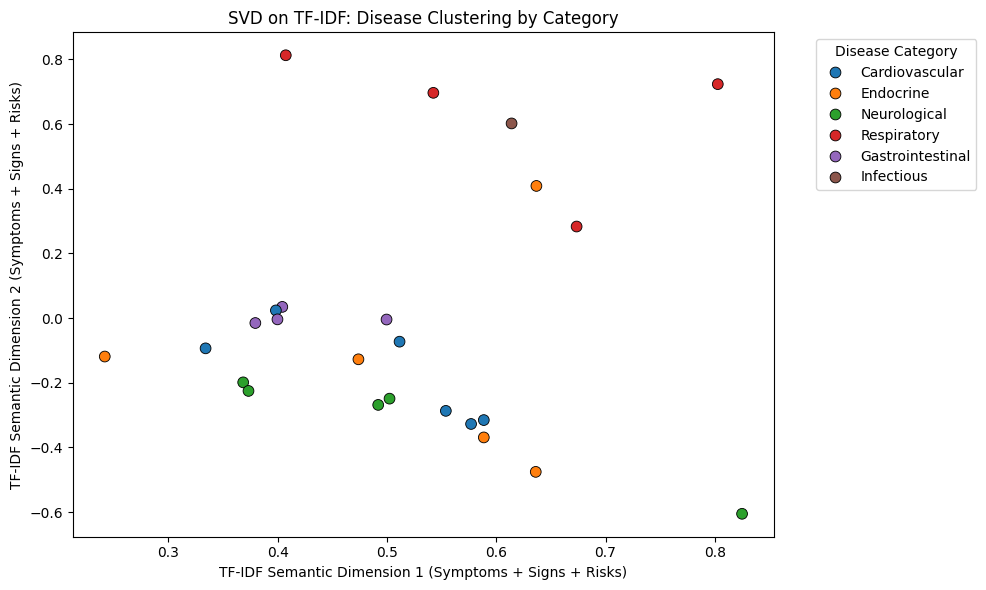

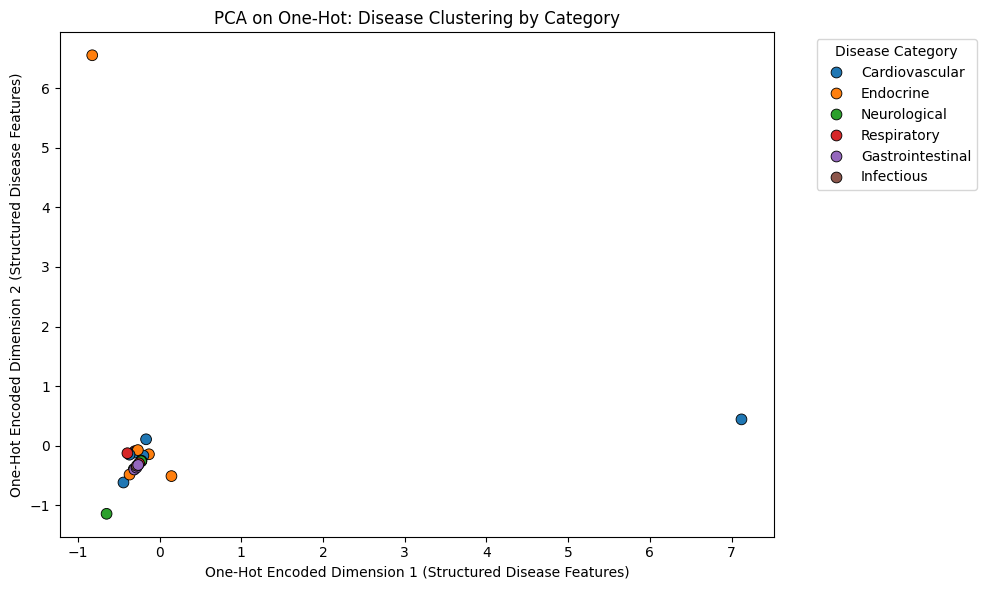

In [3]:
# Task 2: Dimensionality Reduction
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import ast

# Load the datasets
df = pd.read_csv("disease_features.csv")
one_hot = pd.read_csv("encoded_output2.csv")

# Step 1: Parse stringified lists and dictionaries
cols_to_parse = ['Risk Factors', 'Symptoms', 'Signs', 'Subtypes']
for col in cols_to_parse:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
    df[col + '_str'] = df[col].apply(lambda x: ' '.join(x) if isinstance(x, list) else ' '.join(x.keys()))

# Step 2: TF-IDF vectorization
tfidf_risk = TfidfVectorizer().fit_transform(df['Risk Factors_str'])
tfidf_symptoms = TfidfVectorizer().fit_transform(df['Symptoms_str'])
tfidf_signs = TfidfVectorizer().fit_transform(df['Signs_str'])

# Combine TF-IDF features
tfidf_combined = hstack([tfidf_risk, tfidf_symptoms, tfidf_signs])

# Step 3: Dimensionality Reduction — PCA (One-Hot) and SVD (TF-IDF)
one_hot_numeric = one_hot.select_dtypes(include=[np.number])

pca = PCA(n_components=3)
pca_result = pca.fit_transform(one_hot_numeric)

svd = TruncatedSVD(n_components=3)
svd_result = svd.fit_transform(tfidf_combined)

# Step 4: Disease category mapping
disease_category_map = {
    'Asthma': 'Respiratory',
    'COPD': 'Respiratory',
    'Pneumonia': 'Respiratory',
    'Pulmonary Embolism': 'Respiratory',

    'Stroke': 'Neurological',
    'Epilepsy': 'Neurological',
    'Migraine': 'Neurological',
    'Multiple Sclerosis': 'Neurological',
    'Alzheimer': 'Neurological',

    'Heart Failure': 'Cardiovascular',
    'Atrial Fibrillation': 'Cardiovascular',
    'Acute Coronary Syndrome': 'Cardiovascular',
    'Hypertension': 'Cardiovascular',
    'Aortic Dissection': 'Cardiovascular',
    'Cardiomyopathy': 'Cardiovascular',

    'Diabetes': 'Endocrine',
    'Hyperlipidemia': 'Endocrine',
    'Thyroid Disease': 'Endocrine',
    'Pituitary Disease': 'Endocrine',
    'Adrenal Insufficiency': 'Endocrine',

    'Gastritis': 'Gastrointestinal',
    'Peptic Ulcer Disease': 'Gastrointestinal',
    'Gastro-oesophageal Reflux Disease': 'Gastrointestinal',
    'Upper Gastrointestinal Bleeding': 'Gastrointestinal',

    'Tuberculosis': 'Infectious',
}

df['Disease Category'] = df['Disease'].map(disease_category_map)
df['Disease Category'] = df['Disease Category'].fillna('Other')

# Step 5: Explained Variance Reporting
print("\n📊 Explained Variance Ratio:")
print("PCA on One-Hot:", pca.explained_variance_ratio_)
print("SVD on TF-IDF:", svd.explained_variance_ratio_)

print("\n🔢 Total Explained Variance:")
print(f"PCA Total: {np.sum(pca.explained_variance_ratio_):.4f}")
print(f"SVD Total: {np.sum(svd.explained_variance_ratio_):.4f}")

# Step 6: 2D Visualization

svd_x_label = "TF-IDF Semantic Dimension 1 (Symptoms + Signs + Risks)"
svd_y_label = "TF-IDF Semantic Dimension 2 (Symptoms + Signs + Risks)"

pca_x_label = "One-Hot Encoded Dimension 1 (Structured Disease Features)"
pca_y_label = "One-Hot Encoded Dimension 2 (Structured Disease Features)"

# Plot SVD
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=svd_result[:, 0], 
    y=svd_result[:, 1], 
    hue=df['Disease Category'], 
    palette='tab10', 
    s=60, edgecolor='k'
)
plt.title("SVD on TF-IDF: Disease Clustering by Category")
plt.xlabel(svd_x_label)
plt.ylabel(svd_y_label)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Disease Category")
plt.tight_layout()
plt.show()

# Plot PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=pca_result[:, 0], 
    y=pca_result[:, 1], 
    hue=df['Disease Category'], 
    palette='tab10', 
    s=60, edgecolor='k'
)
plt.title("PCA on One-Hot: Disease Clustering by Category")
plt.xlabel(pca_x_label)
plt.ylabel(pca_y_label)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Disease Category")
plt.tight_layout()
plt.show()


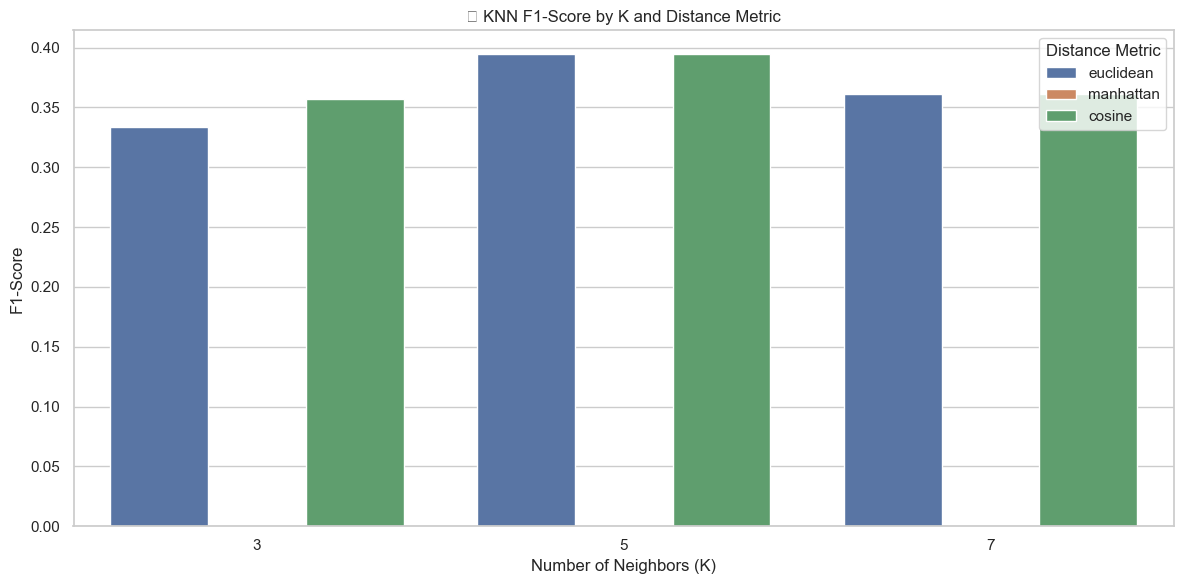

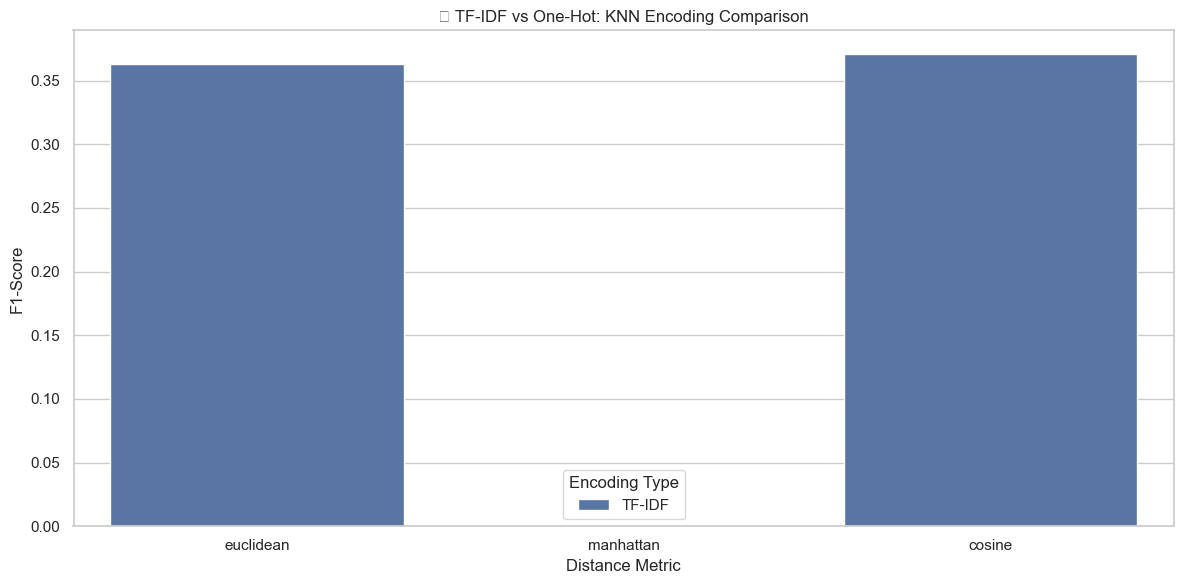

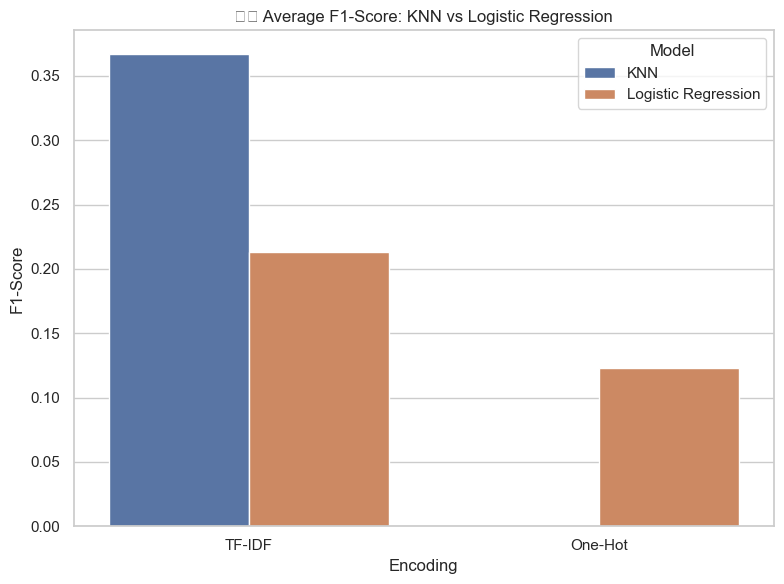


📌 KNN Evaluation Summary:


,Model,Encoding,K,Metric,Accuracy,Precision,Recall,F1-Score
8,KNN,TF-IDF,7,cosine,0.56,0.444667,0.56,0.469333
6,KNN,TF-IDF,7,euclidean,0.56,0.444667,0.56,0.469333
0,KNN,TF-IDF,3,euclidean,0.56,0.436667,0.56,0.469333
2,KNN,TF-IDF,3,cosine,0.56,0.436667,0.56,0.469333
5,KNN,TF-IDF,5,cosine,0.52,0.433333,0.52,0.438667
3,KNN,TF-IDF,5,euclidean,0.52,0.433333,0.52,0.438667
14,KNN,TF-IDF,5,cosine,0.44,0.306667,0.44,0.350667
12,KNN,TF-IDF,5,euclidean,0.44,0.306667,0.44,0.350667
15,KNN,TF-IDF,7,euclidean,0.36,0.210000,0.36,0.253333
17,KNN,TF-IDF,7,cosine,0.36,0.210000,0.36,0.253333



📌 Logistic Regression Evaluation Summary:


,Model,Encoding,Accuracy,F1-Score
0,Logistic Regression,TF-IDF,0.32,0.213333
1,Logistic Regression,One-Hot,0.24,0.122667


In [4]:
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

# Targets
y = df['Disease Category']

# Normalize TF-IDF for cosine distance
tfidf_normalized = normalize(tfidf_combined)
one_hot_normalized = normalize(one_hot_numeric)

# Distance metric map
distance_metrics = {
    'euclidean': 'euclidean',
    'manhattan': 'manhattan',
    'cosine': 'cosine'
}

# KNN evaluation function
def evaluate_knn(X, y, k_values, metrics):
    results = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for k in k_values:
        for metric_name, metric in metrics.items():
            model = KNeighborsClassifier(n_neighbors=k, metric=metric)
            scores = cross_validate(
                model, X, y, cv=cv,
                scoring={
                    'accuracy': make_scorer(accuracy_score),
                    'precision': make_scorer(precision_score, average='weighted'),
                    'recall': make_scorer(recall_score, average='weighted'),
                    'f1': make_scorer(f1_score, average='weighted')
                }
            )
            results.append({
                'Model': 'KNN',
                'Encoding': 'TF-IDF' if X.shape[1] > 100 else 'One-Hot',
                'K': k,
                'Metric': metric_name,
                'Accuracy': np.mean(scores['test_accuracy']),
                'Precision': np.mean(scores['test_precision']),
                'Recall': np.mean(scores['test_recall']),
                'F1-Score': np.mean(scores['test_f1'])
            })
    return results

# Logistic Regression evaluation function
def evaluate_logistic_regression(X, y, encoding_name):
    model = LogisticRegression(max_iter=1000)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(
        model, X, y, cv=cv,
        scoring={
            'accuracy': make_scorer(accuracy_score),
            'f1': make_scorer(f1_score, average='weighted')
        }
    )
    return {
        'Model': 'Logistic Regression',
        'Encoding': encoding_name,
        'Accuracy': np.mean(scores['test_accuracy']),
        'F1-Score': np.mean(scores['test_f1'])
    }

# Run evaluations
k_values = [3, 5, 7]
knn_results_tfidf = evaluate_knn(tfidf_normalized, y, k_values, distance_metrics)
knn_results_onehot = evaluate_knn(one_hot_normalized, y, k_values, distance_metrics)

logreg_result_tfidf = evaluate_logistic_regression(tfidf_normalized, y, 'TF-IDF')
logreg_result_onehot = evaluate_logistic_regression(one_hot_normalized, y, 'One-Hot')

# Combine results
import pandas as pd
knn_df = pd.DataFrame(knn_results_tfidf + knn_results_onehot)
logreg_df = pd.DataFrame([logreg_result_tfidf, logreg_result_onehot])

# ====================📊 VISUALIZATION ====================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1. KNN F1-score by K and distance metric
plt.figure(figsize=(12, 6))
sns.barplot(
    data=knn_df,
    x='K', y='F1-Score',
    hue='Metric', ci=None
)
plt.title("🔍 KNN F1-Score by K and Distance Metric")
plt.ylabel("F1-Score")
plt.xlabel("Number of Neighbors (K)")
plt.legend(title="Distance Metric")
plt.tight_layout()
plt.show()

# 2. TF-IDF vs One-Hot Encoding (KNN only)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=knn_df,
    x='Metric', y='F1-Score',
    hue='Encoding', ci=None
)
plt.title("📊 TF-IDF vs One-Hot: KNN Encoding Comparison")
plt.ylabel("F1-Score")
plt.xlabel("Distance Metric")
plt.legend(title="Encoding Type")
plt.tight_layout()
plt.show()

# 3. Logistic Regression vs KNN (average F1 by encoding)
combined_df = pd.concat([
    knn_df.groupby('Encoding').agg({'F1-Score': 'mean'}).reset_index().assign(Model='KNN'),
    logreg_df[['Encoding', 'F1-Score']].assign(Model='Logistic Regression')
])

plt.figure(figsize=(8, 6))
sns.barplot(data=combined_df, x='Encoding', y='F1-Score', hue='Model')
plt.title("⚖️ Average F1-Score: KNN vs Logistic Regression")
plt.ylabel("F1-Score")
plt.tight_layout()
plt.show()

# ====================📋 TEXT SUMMARY ====================
print("\n📌 KNN Evaluation Summary:")
display(knn_df.sort_values(by='F1-Score', ascending=False))

print("\n📌 Logistic Regression Evaluation Summary:")
display(logreg_df.sort_values(by='F1-Score', ascending=False))


In [1]:
from IPython.display import display, Markdown

# The report content
report = """
# Task 4: Critical Analysis

### 1. Why TF-IDF might outperform One-Hot Encoding (or vice versa) for this dataset:

**TF-IDF (Term Frequency-Inverse Document Frequency)** and **One-Hot Encoding** are two distinct methods of converting text data into numeric representations, and each has its strengths and weaknesses depending on the nature of the data and the task at hand.

#### Why TF-IDF might outperform One-Hot Encoding:

- **Handling of Word Importance**:  
  TF-IDF assigns higher weight to terms that are more unique and informative, down-weighting common words that appear in most documents. In the context of this dataset, where diseases and their symptoms, risk factors, and signs are involved, certain terms (e.g., "chest pain" for cardiovascular diseases, "wheezing" for respiratory diseases) are much more discriminative in classifying diseases. TF-IDF emphasizes these terms, allowing for better differentiation between diseases based on the occurrence of rare, disease-specific words.

- **Dimensionality Reduction**:  
  TF-IDF naturally leads to sparse feature vectors, but it often results in a smaller matrix when compared to one-hot encoding, as it only considers the words that appear in the documents, and the weights are derived from the term frequency and inverse document frequency. This makes TF-IDF more efficient and potentially reduces overfitting, especially when there are many unique terms.

- **Capturing Semantic Meaning**:  
  Unlike One-Hot Encoding, which treats each word or feature as equally important, TF-IDF captures the relative importance of a term in a given context (document). This is crucial for disease classification, where some symptoms or risk factors might appear only in specific diseases, making them more relevant for classification.

#### Why One-Hot Encoding might outperform TF-IDF:

- **Simplicity**:  
  One-Hot Encoding is straightforward and results in binary features, which can be easy to interpret. For disease classification, where the presence or absence of certain features (risk factors, symptoms) is more important than the frequency of those features, One-Hot Encoding can sometimes perform just as well, especially when the relationships between terms are not semantic but more structural.

- **Unambiguous Representation**:  
  One-Hot Encoding ensures that each feature is treated as a separate, independent entity. This can be beneficial in situations where the order or frequency of terms is irrelevant, and the goal is to capture the presence or absence of a feature. For example, the risk factor "smoking" either exists or does not, and One-Hot Encoding represents this unambiguously.

- **Sparse Data**:  
  One-Hot Encoding can sometimes perform better when the number of distinct features is not very large or when the dataset is sparse. While TF-IDF reduces dimensionality, it can still lead to a sparse matrix if many terms are used that are not strongly correlated with the disease categories.

### 2. Clinical Relevance of the Results:

The clinical relevance of the results largely depends on how well the encoded features (TF-IDF vs. One-Hot) help classify the diseases into appropriate categories. In this dataset, the goal is to predict the disease categories (e.g., cardiovascular, respiratory, neurological) based on risk factors, symptoms, and signs.

#### TF-IDF Clusters and Disease Categories:

- **TF-IDF clusters** often align better with real-world disease categories when the distinguishing features between diseases are based on specific terms that are unique to certain diseases. For instance, **cardiovascular diseases** like **Acute Coronary Syndrome** are associated with terms like "chest pain", "nausea", and "heart attack", which may appear more prominently in the dataset for these diseases, and TF-IDF will give these terms higher weight. This allows the model to better distinguish between diseases by focusing on the most relevant words for each category.

- In contrast, **One-Hot Encoding** doesn't capture the relative importance of terms, but only whether a particular feature is present or not. While it can be useful for representing the presence or absence of symptoms or risk factors, it may not be as effective in grouping diseases where the key distinguishing terms are more subtle or varied.

#### Disease Categories and Semantic Similarity:
TF-IDF helps in capturing more semantic distinctions, which can be especially important for diseases that share common risk factors or symptoms (e.g., respiratory diseases like **Asthma** and **COPD**). If these diseases share many symptoms but differ on a few specific ones, TF-IDF will better capture these subtle distinctions by assigning higher weights to those discriminative terms.

### 3. Limitations of Both Encoding Methods:

#### Limitations of TF-IDF:

- **Loss of Context**: While TF-IDF highlights important words, it fails to capture the relationships between words. For example, the term "heart disease" will be treated differently from "heart failure" despite both being highly related. TF-IDF cannot capture the semantic relationships between words unless combined with advanced techniques like word embeddings (e.g., Word2Vec or GloVe).

- **Dependence on Document Length**: TF-IDF can be sensitive to the length of the documents. Longer documents may naturally have higher term frequencies, which might skew the representation. In contrast, One-Hot Encoding does not suffer from this issue because each word is treated equally, regardless of document length.

- **Feature Explosion**: Although TF-IDF is generally more efficient than One-Hot Encoding in terms of the feature space, it can still result in a very high-dimensional matrix when dealing with a large vocabulary (such as in medical datasets with a broad range of symptoms and risk factors). This can lead to **curse of dimensionality** problems in some machine learning models.

#### Limitations of One-Hot Encoding:

- **Sparsity**: One-Hot Encoding results in sparse vectors, which can lead to inefficiencies, especially in datasets with a large vocabulary. This may cause issues when training models, as many features will have no value (i.e., they will be zero for most instances).

- **Lack of Semantic Understanding**: One-Hot Encoding treats all features as independent and doesn't account for any relationships between terms. For example, if both **Asthma** and **Chronic Obstructive Pulmonary Disease (COPD)** share the risk factor "smoking", One-Hot Encoding will treat "smoking" as a separate feature for both, even though they are related in meaning.

- **Large Feature Space**: In datasets with many unique terms or categories, One-Hot Encoding can lead to an excessively large feature space, which may cause issues with computation time and model performance. It also makes the model less interpretable, as it doesn't capture any word associations.

### Conclusion:

- **TF-IDF** is particularly useful when the **importance** of terms varies across documents, as it weighs rare but important terms more heavily. This makes it a better fit for tasks where distinguishing between diseases based on specific symptoms or risk factors is important.

- **One-Hot Encoding**, on the other hand, is more straightforward and might work well when the presence or absence of features (such as specific symptoms or risk factors) is crucial, and when there is less concern about the relative importance of those features.

In terms of **clinical relevance**, TF-IDF offers more potential for accurately grouping diseases based on subtle differences in terminology, but One-Hot Encoding remains a reliable method for representing categorical data without adding unnecessary complexity.

Both encoding methods have their place depending on the context, but **TF-IDF** seems better suited to medical classification tasks where the terms used to describe diseases are more diverse and nuanced. However, it's essential to balance the complexity and interpretability of the models based on the use case.
"""

# Display the report in Jupyter Notebook
display(Markdown(report))



# Task 4: Critical Analysis

### 1. Why TF-IDF might outperform One-Hot Encoding (or vice versa) for this dataset:

**TF-IDF (Term Frequency-Inverse Document Frequency)** and **One-Hot Encoding** are two distinct methods of converting text data into numeric representations, and each has its strengths and weaknesses depending on the nature of the data and the task at hand.

#### Why TF-IDF might outperform One-Hot Encoding:

- **Handling of Word Importance**:  
  TF-IDF assigns higher weight to terms that are more unique and informative, down-weighting common words that appear in most documents. In the context of this dataset, where diseases and their symptoms, risk factors, and signs are involved, certain terms (e.g., "chest pain" for cardiovascular diseases, "wheezing" for respiratory diseases) are much more discriminative in classifying diseases. TF-IDF emphasizes these terms, allowing for better differentiation between diseases based on the occurrence of rare, disease-specific words.

- **Dimensionality Reduction**:  
  TF-IDF naturally leads to sparse feature vectors, but it often results in a smaller matrix when compared to one-hot encoding, as it only considers the words that appear in the documents, and the weights are derived from the term frequency and inverse document frequency. This makes TF-IDF more efficient and potentially reduces overfitting, especially when there are many unique terms.

- **Capturing Semantic Meaning**:  
  Unlike One-Hot Encoding, which treats each word or feature as equally important, TF-IDF captures the relative importance of a term in a given context (document). This is crucial for disease classification, where some symptoms or risk factors might appear only in specific diseases, making them more relevant for classification.

#### Why One-Hot Encoding might outperform TF-IDF:

- **Simplicity**:  
  One-Hot Encoding is straightforward and results in binary features, which can be easy to interpret. For disease classification, where the presence or absence of certain features (risk factors, symptoms) is more important than the frequency of those features, One-Hot Encoding can sometimes perform just as well, especially when the relationships between terms are not semantic but more structural.

- **Unambiguous Representation**:  
  One-Hot Encoding ensures that each feature is treated as a separate, independent entity. This can be beneficial in situations where the order or frequency of terms is irrelevant, and the goal is to capture the presence or absence of a feature. For example, the risk factor "smoking" either exists or does not, and One-Hot Encoding represents this unambiguously.

- **Sparse Data**:  
  One-Hot Encoding can sometimes perform better when the number of distinct features is not very large or when the dataset is sparse. While TF-IDF reduces dimensionality, it can still lead to a sparse matrix if many terms are used that are not strongly correlated with the disease categories.

### 2. Clinical Relevance of the Results:

The clinical relevance of the results largely depends on how well the encoded features (TF-IDF vs. One-Hot) help classify the diseases into appropriate categories. In this dataset, the goal is to predict the disease categories (e.g., cardiovascular, respiratory, neurological) based on risk factors, symptoms, and signs.

#### TF-IDF Clusters and Disease Categories:

- **TF-IDF clusters** often align better with real-world disease categories when the distinguishing features between diseases are based on specific terms that are unique to certain diseases. For instance, **cardiovascular diseases** like **Acute Coronary Syndrome** are associated with terms like "chest pain", "nausea", and "heart attack", which may appear more prominently in the dataset for these diseases, and TF-IDF will give these terms higher weight. This allows the model to better distinguish between diseases by focusing on the most relevant words for each category.

- In contrast, **One-Hot Encoding** doesn't capture the relative importance of terms, but only whether a particular feature is present or not. While it can be useful for representing the presence or absence of symptoms or risk factors, it may not be as effective in grouping diseases where the key distinguishing terms are more subtle or varied.

#### Disease Categories and Semantic Similarity:
TF-IDF helps in capturing more semantic distinctions, which can be especially important for diseases that share common risk factors or symptoms (e.g., respiratory diseases like **Asthma** and **COPD**). If these diseases share many symptoms but differ on a few specific ones, TF-IDF will better capture these subtle distinctions by assigning higher weights to those discriminative terms.

### 3. Limitations of Both Encoding Methods:

#### Limitations of TF-IDF:

- **Loss of Context**: While TF-IDF highlights important words, it fails to capture the relationships between words. For example, the term "heart disease" will be treated differently from "heart failure" despite both being highly related. TF-IDF cannot capture the semantic relationships between words unless combined with advanced techniques like word embeddings (e.g., Word2Vec or GloVe).

- **Dependence on Document Length**: TF-IDF can be sensitive to the length of the documents. Longer documents may naturally have higher term frequencies, which might skew the representation. In contrast, One-Hot Encoding does not suffer from this issue because each word is treated equally, regardless of document length.

- **Feature Explosion**: Although TF-IDF is generally more efficient than One-Hot Encoding in terms of the feature space, it can still result in a very high-dimensional matrix when dealing with a large vocabulary (such as in medical datasets with a broad range of symptoms and risk factors). This can lead to **curse of dimensionality** problems in some machine learning models.

#### Limitations of One-Hot Encoding:

- **Sparsity**: One-Hot Encoding results in sparse vectors, which can lead to inefficiencies, especially in datasets with a large vocabulary. This may cause issues when training models, as many features will have no value (i.e., they will be zero for most instances).

- **Lack of Semantic Understanding**: One-Hot Encoding treats all features as independent and doesn't account for any relationships between terms. For example, if both **Asthma** and **Chronic Obstructive Pulmonary Disease (COPD)** share the risk factor "smoking", One-Hot Encoding will treat "smoking" as a separate feature for both, even though they are related in meaning.

- **Large Feature Space**: In datasets with many unique terms or categories, One-Hot Encoding can lead to an excessively large feature space, which may cause issues with computation time and model performance. It also makes the model less interpretable, as it doesn't capture any word associations.

### Conclusion:

- **TF-IDF** is particularly useful when the **importance** of terms varies across documents, as it weighs rare but important terms more heavily. This makes it a better fit for tasks where distinguishing between diseases based on specific symptoms or risk factors is important.

- **One-Hot Encoding**, on the other hand, is more straightforward and might work well when the presence or absence of features (such as specific symptoms or risk factors) is crucial, and when there is less concern about the relative importance of those features.

In terms of **clinical relevance**, TF-IDF offers more potential for accurately grouping diseases based on subtle differences in terminology, but One-Hot Encoding remains a reliable method for representing categorical data without adding unnecessary complexity.

Both encoding methods have their place depending on the context, but **TF-IDF** seems better suited to medical classification tasks where the terms used to describe diseases are more diverse and nuanced. However, it's essential to balance the complexity and interpretability of the models based on the use case.
